# E01 — tout initialiser à zéro

Karpathy annonce que le réseau ne s'entraîne ni bien ni pas du tout si tous les paramétres sont à 0: il s'entraîne **partiellement**.
Il faut trouver quelle partie apprend, et pourquoi le reste est bloqué.

In [1]:
import random
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
vocab_size = len(itos)

random.seed(42)
ws = words[:]
random.shuffle(ws)
n1, n2 = int(0.8 * len(ws)), int(0.9 * len(ws))

block_size = 3

def build_dataset(words):
	X, Y = [], []
	for w in words:
		context = [0] * block_size
		for ch in w + '.':
			ix = stoi[ch]
			X.append(context)
			Y.append(ix)
			context = context[1:] + [ix]
	X = torch.tensor(X)
	Y = torch.tensor(Y)
	print(X.shape, Y.shape)
	return X, Y

Xtr, Ytr = build_dataset(ws[:n1])
Xdev, Ydev = build_dataset(ws[n1:n2])
Xte, Yte = build_dataset(ws[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


## Init à zéro

In [2]:
n_embd = 10
n_hidden = 200
eps = 1e-5

g = torch.Generator().manual_seed(2147483647)
C = torch.zeros((vocab_size, n_embd))
W1 = torch.zeros((block_size * n_embd, n_hidden))
W2 = torch.zeros((n_hidden, vocab_size))
b2 = torch.zeros(vocab_size)

bngain = torch.zeros((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

names = ['C', 'W1', 'W2', 'b2', 'bngain', 'bnbias']
parameters = [C, W1, W2, b2, bngain, bnbias]
for p in parameters:
	p.requires_grad = True

In [3]:
max_steps = 200000
batch_size = 64
lossi = []
grads0 = {}

for i in range(max_steps):
	ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
	Xb, Yb = Xtr[ix], Ytr[ix]

	#forward pass
	emb = C[Xb]
	embcat = emb.view(emb.shape[0], -1)
	hpreact = embcat @ W1
	bnmeani = hpreact.mean(0, keepdim=True)
	bnstdi = (hpreact.var(0, keepdim=True) + eps).sqrt()
	hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

	with torch.no_grad():
		bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
		bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

	h = torch.tanh(hpreact)
	logits = h @ W2 + b2
	loss = F.cross_entropy(logits, Yb)

	#backward pass
	for p in parameters:
		p.grad = None
	loss.backward()

	# gradients du tout premier step, pour le diagnostic
	if i == 0:
		grads0 = {n: p.grad.abs().max().item() for n, p in zip(names, parameters)}

	#update
	lr = 0.1 if i < 100000 else 0.01
	for p in parameters:
		p.data -= lr * p.grad

	lossi.append(loss.log10().item())
	if i % 10000 == 0:
		print(f"{i:7d}/{max_steps:7d} : {loss.item():.4f}")

      0/ 200000 : 3.2958
  10000/ 200000 : 2.8200
  20000/ 200000 : 2.8831
  30000/ 200000 : 2.7956
  40000/ 200000 : 2.6975
  50000/ 200000 : 2.8349
  60000/ 200000 : 2.7105
  70000/ 200000 : 2.8483
  80000/ 200000 : 2.7916
  90000/ 200000 : 3.0775
 100000/ 200000 : 2.8823
 110000/ 200000 : 2.7618
 120000/ 200000 : 2.8672
 130000/ 200000 : 2.8002
 140000/ 200000 : 2.7532
 150000/ 200000 : 2.8574
 160000/ 200000 : 3.0022
 170000/ 200000 : 2.7902
 180000/ 200000 : 2.6660
 190000/ 200000 : 2.8130


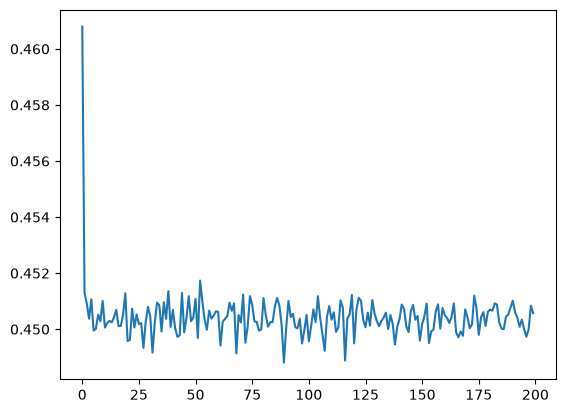

In [4]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1));

In [5]:
@torch.no_grad()
def split_loss(split):
	x, y = {
		'train': (Xtr, Ytr),
		'dev': (Xdev, Ydev),
		'test' : (Xte, Yte)
	}[split]
	emb = C[x]
	embcat = emb.view(emb.shape[0], -1)
	hpreact = embcat @ W1
	hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
	h = torch.tanh(hpreact)
	logits = h @ W2 + b2
	loss = F.cross_entropy(logits, y)
	print(split, loss.item())

split_loss('train')
split_loss('dev')

train 2.8226475715637207
dev 2.8210396766662598


## Diagnostic

In [6]:
print(f"{'param':>7} | {'grad step 0':>11} | {'grad final':>10} | {'|data| max':>10}")
for n, p in zip(names, parameters):
	print(f"{n:>7} | {grads0[n]:11.2e} | {p.grad.abs().max().item():10.2e} | {p.data.abs().max().item():10.2e}")

print('h max :', h.abs().max().item())

  param | grad step 0 | grad final | |data| max
      C |    0.00e+00 |   0.00e+00 |   0.00e+00
     W1 |    0.00e+00 |   0.00e+00 |   0.00e+00
     W2 |    0.00e+00 |   0.00e+00 |   0.00e+00
     b2 |    1.35e-01 |   6.24e-02 |   2.84e+00
 bngain |    0.00e+00 |   0.00e+00 |   0.00e+00
 bnbias |    0.00e+00 |   0.00e+00 |   0.00e+00
h max : 0.0


## Ce que `b2` a appris

In [7]:
freq = torch.bincount(Ytr, minlength=vocab_size).float()
freq /= freq.sum()
p_b2 = F.softmax(b2.detach(), dim=0)

print('écart max softmax(b2) / fréquences :', (p_b2 - freq).abs().max().item())

# loss du modèle unigramme compté, sur le dev
print('unigramme dev :', -freq[Ydev].log().mean().item())

écart max softmax(b2) / fréquences : 0.0023642778396606445
unigramme dev : 2.821019172668457


## Conclusion

Au step 0, tout est nul, donc `h = tanh(0) = 0` pour tous les exemples et `logits = 0`.
La loss vaut `log(27) ≈ 3.30`, et `dlogits = probs - onehot` n'est **pas** nul.

On remonte la backprop :

- `db2 = dlogits.sum(0)` est non nul, donc `b2` apprend.
- `dW2 = h.T @ dlogits = 0`, parce que `h = 0`.
- `dh = dlogits @ W2.T = 0`, parce que `W2 = 0`. Tout ce qui est en amont (`bnbias`, `bngain`, `W1`, `C`) reçoit un gradient nul.

Rien ne change au step suivant : `h` reste à 0, donc `W2` reste à 0, donc le chemin reste coupé.
C'est un point fixe. Seul `b2` s'entraîne, et il converge vers le log des fréquences des caractères.
Le réseau devient un unigramme qui ignore complètement le contexte, d'où une loss bien pire que les ~2.1 de `from_scratch`.

Il faut deux zéros en série pour tout bloquer : `h = 0` (parce que `tanh(0) = 0`) **et** `W2 = 0`.
Si seul `W2` valait 0 avec le reste aléatoire, `h` serait non nul, `W2` recevrait un gradient dès le step 0,
et le chemin se rouvrirait au step suivant.